<a href="https://colab.research.google.com/github/o-kauan/CP2_SEM2_SERS_2026/blob/main/Checkpoint2_SERS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [23]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [24]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [25]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Três classificadores de famílias distintas
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [27]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [28]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


Informações do Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB
None

Primeiras Linhas
   potencia_kw   latitude  longitude  fonte
0        20.48 -10.442778 -64.151944  Solar
1      5000.00  -6.003889 -40.274722  Solar
2        12.26 -23.557778 -46.734000  Solar
3         3.00 -23.558889 -46.735000  Solar
4         1.70 -23.493819 -46.845000  Solar

Valores Ausentes por Coluna
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Contagem e Proporção por Classe (y)
            Quantidade  Proporção (%)
fonte                                
Hidráulica        1476      38.080495
Solar            

/tmp/ipykernel_2894/2294129227.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_aneel, x='fonte', palette='viridis')


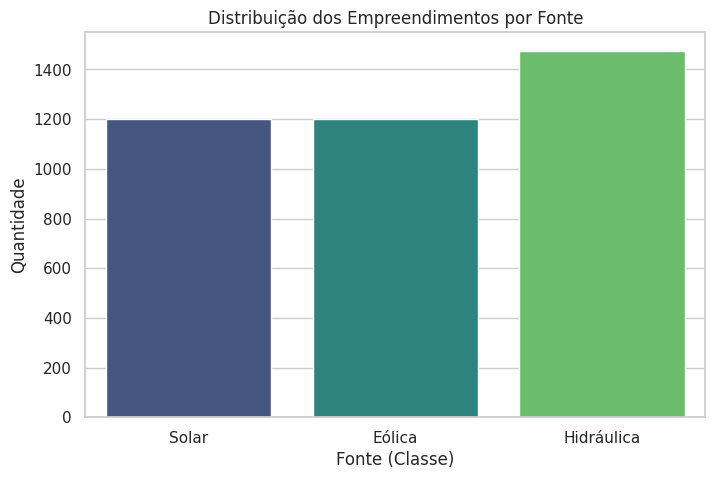

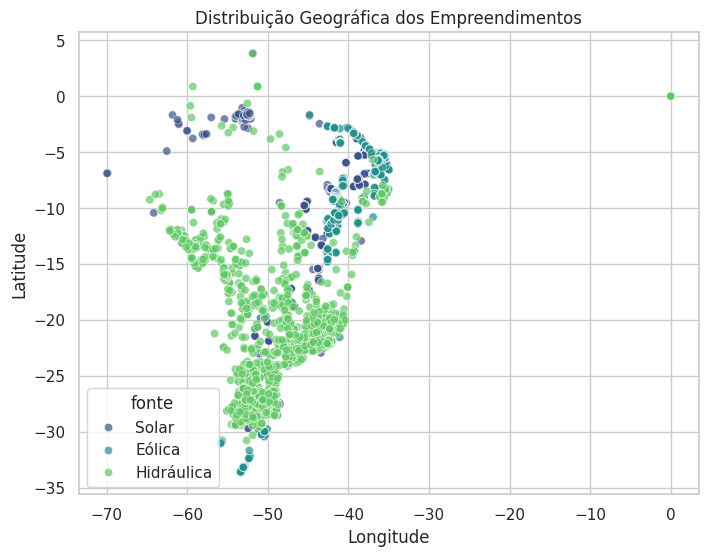

In [29]:

df_aneel = pd.read_csv("aneel_classificacao_orange.csv")

print("Informações do Dataset")
print(df_aneel.info())
print("\nPrimeiras Linhas")
print(df_aneel.head())

print("\nValores Ausentes por Coluna")
print(df_aneel.isnull().sum())

print("\nContagem e Proporção por Classe (y)")
contagem_classes = df_aneel['fonte'].value_counts()
proporcao_classes = df_aneel['fonte'].value_counts(normalize=True) * 100
df_distrib = pd.DataFrame({'Quantidade': contagem_classes, 'Proporção (%)': proporcao_classes})
print(df_distrib)

# Visualização da distribuição das classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df_aneel, x='fonte', palette='viridis')
plt.title("Distribuição dos Empreendimentos por Fonte")
plt.xlabel("Fonte (Classe)")
plt.ylabel("Quantidade")
plt.show()

# Visualização espacial dos empreendimentos
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_aneel, x='longitude', y='latitude', hue='fonte', alpha=0.7, palette='viridis')
plt.title("Distribuição Geográfica dos Empreendimentos")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

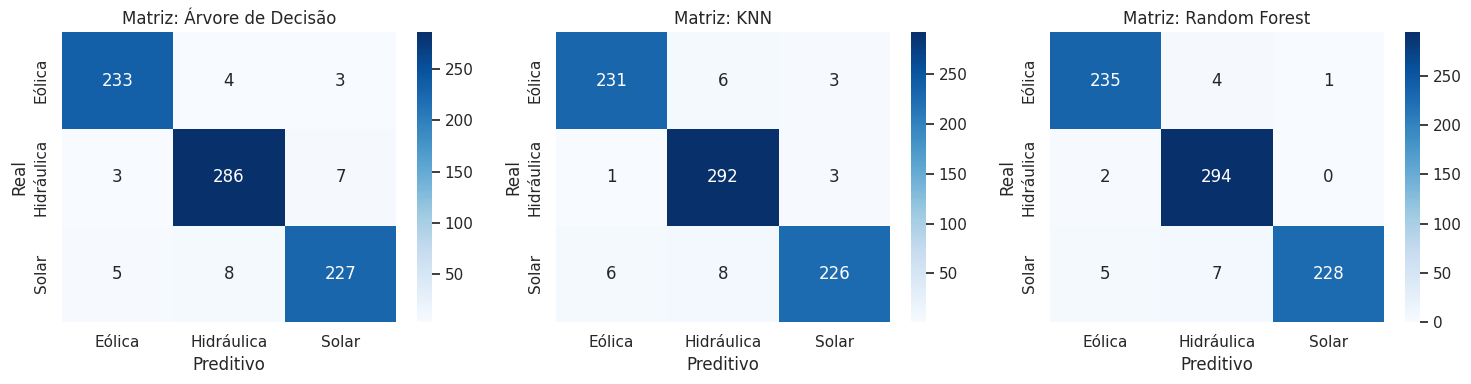


TABELA COMPARATIVA DOS MODELOS
        Algoritmo  Acurácia  Precisão (Macro)  Recall (Macro)  F1-Score (Macro)
Árvore de Decisão    0.9613            0.9614          0.9610            0.9612
              KNN    0.9652            0.9663          0.9636            0.9648
    Random Forest    0.9755            0.9769          0.9741            0.9753


In [30]:
# Divisão Estratificada, Treinamento dos Modelos e Métricas

# 1. Definição estrita das entradas (X) e do alvo (y)
X = df_aneel[['potencia_kw', 'latitude', 'longitude']]
y = df_aneel['fonte']

# 2. Divisão estratificada (80% Treino / 20% Teste) com semente fixa
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Ajuste de escala APENAS no conjunto de treino (sem vazamento de dados)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Definição dos 3 classificadores de famílias distintas
modelos = {
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

resultados = []

# 5. Treinamento e geração dos gráficos das Matrizes de Confusão
plt.figure(figsize=(15, 4))

for idx, (nome, modelo) in enumerate(modelos.items(), 1):
    # O KNN exige dados padronizados; Árvores utilizam os originais
    if nome == "KNN":
        modelo.fit(X_train_scaled, y_train)
        y_pred = modelo.predict(X_test_scaled)
    else:
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)

    # Cálculo das métricas globais e médias por classe (MACRO)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')

    resultados.append({
        "Algoritmo": nome,
        "Acurácia": round(acc, 4),
        "Precisão (Macro)": round(prec, 4),
        "Recall (Macro)": round(rec, 4),
        "F1-Score (Macro)": round(f1, 4)
    })

    # Plotagem da Matriz de Confusão
    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    plt.subplot(1, 3, idx)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=modelo.classes_, yticklabels=modelo.classes_)
    plt.title(f"Matriz: {nome}")
    plt.xlabel("Preditivo")
    plt.ylabel("Real")

plt.tight_layout()
plt.show()

# 6. Exibição da Tabela Comparativa final
df_comparacao = pd.DataFrame(resultados)
print("\nTABELA COMPARATIVA DOS MODELOS")
print(df_comparacao.to_string(index=False))

### Interpretacao Escrita e Analise Critica

1. Explicacao das Variaveis:
   * Entradas (X): potencia_kw (capacidade de geracao em kW), latitude e longitude (coordenadas geograficas). Nenhuma outra variavel como nomes, CEG ou siglas foi utilizada para evitar atalhos e vazamento de informacao.
   * Alvo (y): fonte (Solar, Eolica e Hidraulica).

2. Divisao e Padronizacao de Escala:
   * Foi utilizada a proporcao de 80% para treino e 20% para teste com divisao estratificada (stratify=y) e semente fixa (random_state=42).
   * A padronizacao (StandardScaler) foi ajustada (fit) exclusivamente no conjunto de treino e apenas aplicada (transform) no conjunto de teste, garantindo que as estatisticas do teste nao afetem o aprendizado.

3. Metricas Escolhidas:
   * Optou-se pela media Macro (average='macro') para Precisao, Recall e F1-Score, avaliando o desempenho de forma equilibrada em cada classe individualmente antes de calcular a media.

4. Escolha do Modelo e Confusao entre Classes:
   * O Random Forest obteve o melhor desempenho geral em todas as metricas devido a sua capacidade de combinar multiplas arvores e capturar padroes nao lineares complexos.
   * Pela matriz de confusao, nota-se uma ligeira confusao em regioes onde pequenas usinas Hidraulicas e parques Solares possuem faixas de potencia e localizacao geografica muito aproximadas.

5. Por que Potencia e Localizacao nao bastam para uma aplicacao real?
   * Fatores Climaticos e Recursos: Apenas as coordenadas geograficas nao informam a vazao dos rios (para hidraulicas), nem os niveis de irradiacao solar ou a constancia e velocidade dos ventos (para eolicas).
   * Sobreposicao Territorial: Em diversas regioes do Brasil (como no Nordeste), complexos solares e parques eolicos coexistem no mesmo quadrante geografico com potencias similares, tornando impossivel diferencia-los unicamente por latitude, longitude e potencia_kw.

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [31]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [32]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [33]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [34]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

## Resolução — Regressão da radiação solar (Petrolina/PE)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42

### Carregar o CSV, explicar as colunas e checar valores ausentes

In [36]:
df = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
df = df.sort_values("data_hora").reset_index(drop=True)   # garante a ordem temporal

print("Formato (linhas, colunas):", df.shape)
print("\nTipos das colunas:\n", df.dtypes)
print("\nValores ausentes por coluna:\n", df.isna().sum())
df.head()

Formato (linhas, colunas): (1001, 7)

Tipos das colunas:
 data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes por coluna:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0


### Explicação das Colunas

- `data_hora`: Data e hora local de cada registro, em formato `YYYY-MM-DD HH:MM:SS`.
- `temperatura_c`: Temperatura do ar a 2 metros de altura, em graus Celsius (°C).
- `umidade_pct`: Umidade relativa do ar a 2 metros de altura, em percentual (%).
- `nuvens_pct`: Cobertura total de nuvens, em percentual (%).
- `vento_kmh`: Velocidade do vento a 10 metros de altura, em quilômetros por hora (km/h).
- `hora`: Hora local extraída de `data_hora`, variando de 7 a 17.
- `radiacao_w_m2`: Radiação solar global horizontal média da hora anterior, em Watts por metro quadrado (W/m²). Este é o nosso **alvo** para a regressão.

In [37]:
df.describe().round(2)

,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,2025-05-16 11:59:59.999999744,28.89,50.54,55.11,15.47,12.00,472.85
min,2025-04-01 07:00:00,19.50,21.00,0.00,2.30,7.00,13.00
25%,2025-04-23 15:00:00,26.30,38.00,19.00,12.20,9.00,250.00
50%,2025-05-16 12:00:00,29.10,49.00,54.00,15.40,12.00,466.00
75%,2025-06-08 09:00:00,31.70,61.00,98.00,19.00,15.00,696.00
max,2025-06-30 17:00:00,36.10,95.00,100.00,30.10,17.00,1002.00
std,NaN,3.66,15.91,37.85,4.92,3.16,256.37


Visualizações

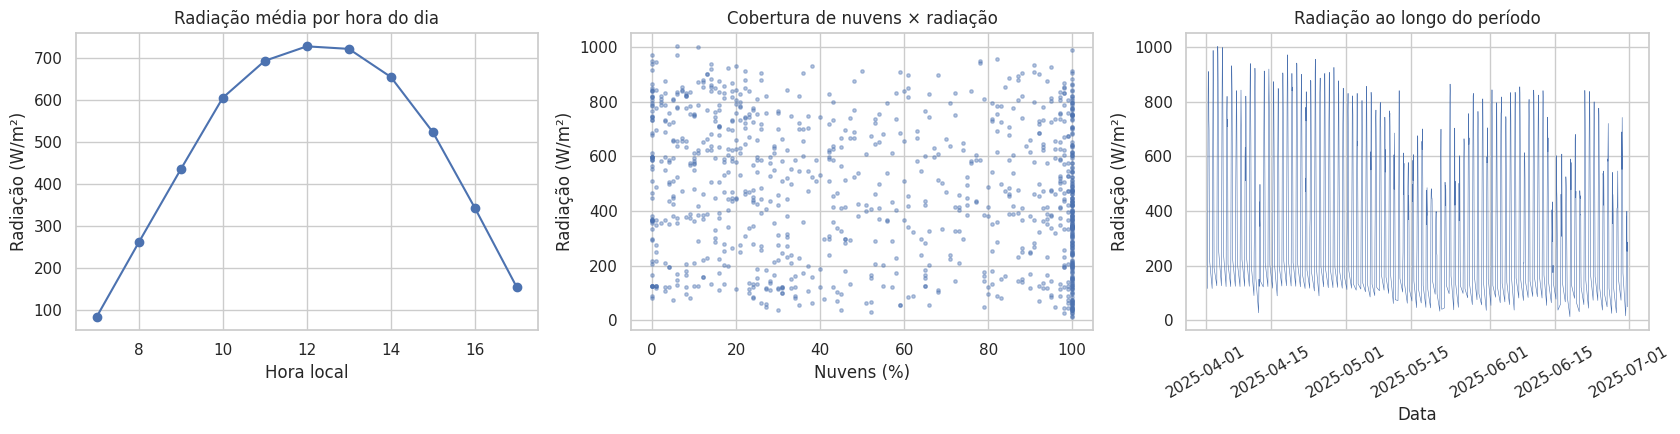

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) Radiação média por hora do dia
df.groupby("hora")["radiacao_w_m2"].mean().plot(ax=ax[0], marker="o")
ax[0].set_title("Radiação média por hora do dia")
ax[0].set_xlabel("Hora local"); ax[0].set_ylabel("Radiação (W/m²)")

# (b) Nuvens x radiação
ax[1].scatter(df["nuvens_pct"], df["radiacao_w_m2"], s=6, alpha=0.4)
ax[1].set_title("Cobertura de nuvens × radiação")
ax[1].set_xlabel("Nuvens (%)"); ax[1].set_ylabel("Radiação (W/m²)")

# (c) Série temporal da radiação
ax[2].plot(df["data_hora"], df["radiacao_w_m2"], lw=0.4)
ax[2].set_title("Radiação ao longo do período")
ax[2].set_xlabel("Data"); ax[2].set_ylabel("Radiação (W/m²)")
ax[2].tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()

### Entendendo as Visualizações

- **Radiação média por hora do dia:** Este gráfico de linha mostra como a radiação solar média varia ao longo das horas do dia, revelando um padrão de "sino", com pico por volta do meio-dia.
- **Cobertura de nuvens × radiação:** O gráfico de dispersão ilustra a relação entre a porcentagem de cobertura de nuvens e a radiação solar. Ele sugere que, geralmente, quanto maior a cobertura de nuvens, menor a radiação, embora haja bastante dispersão.
- **Radiação ao longo do período:** Esta série temporal exibe a variação da radiação solar hora a hora ao longo de todo o período analisado, destacando os padrões diários de subida e descida.

In [39]:
# Correlação de cada variável com a radiação
df.drop(columns="data_hora").corr()["radiacao_w_m2"].drop("radiacao_w_m2").round(3).sort_values()

,radiacao_w_m2
umidade_pct,-0.596
vento_kmh,-0.229
nuvens_pct,-0.180
hora,0.120
temperatura_c,0.643


### Definir X e y e dividir no tempo (80% treino / 20% teste, sem embaralhar)

- **X** = `temperatura_c`, `umidade_pct`, `nuvens_pct`, `vento_kmh`, `hora` (5 entradas)
- **y** = `radiacao_w_m2`

Como as linhas já estão em ordem de `data_hora`, as primeiras 80% viram treino e as 20% finais viram teste. Assim o modelo é testado em datas que ele nunca viu, como aconteceria numa previsão real.

In [40]:
colunas_x = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
alvo = "radiacao_w_m2"

corte = int(len(df) * 0.8)
X_treino, X_teste = df.loc[:corte - 1, colunas_x], df.loc[corte:, colunas_x]
y_treino, y_teste = df.loc[:corte - 1, alvo],      df.loc[corte:, alvo]

print(f"Treino: {len(X_treino)} linhas | {df.loc[0, 'data_hora']} -> {df.loc[corte - 1, 'data_hora']}")
print(f"Teste : {len(X_teste)} linhas | {df.loc[corte, 'data_hora']} -> {df.loc[len(df) - 1, 'data_hora']}")

Treino: 800 linhas | 2025-04-01 07:00:00 -> 2025-06-12 14:00:00
Teste : 201 linhas | 2025-06-12 15:00:00 -> 2025-06-30 17:00:00


### 5. Três algoritmos de regressão

| Algoritmo | Por que foi escolhido |
|---|---|
| **Regressão Linear** | Modelo mais simples, serve de referência. Mostra o quanto uma relação linear consegue explicar. |
| **Random Forest** | Conjunto de árvores; captura relações **não lineares** e interações (por exemplo, hora × nuvens) e é robusto a ruído. |
| **Gradient Boosting** | Árvores construídas em sequência, cada uma corrigindo os erros da anterior; costuma ter bom desempenho em dados tabulares. |

In [41]:
modelos = {
    "Regressão Linear": make_pipeline(StandardScaler(), LinearRegression()),
    "Random Forest": make_pipeline(StandardScaler(),
                                   RandomForestRegressor(n_estimators=200, random_state=SEED)),
    "Gradient Boosting": make_pipeline(StandardScaler(),
                                       GradientBoostingRegressor(random_state=SEED)),
}

resultados, previsoes = [], {}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)          # aprende só com o treino
    pred = modelo.predict(X_teste)          # avalia no teste (período final)
    previsoes[nome] = pred
    resultados.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste, pred),
        "MSE ((W/m²)²)": mean_squared_error(y_teste, pred),
        "R²": r2_score(y_teste, pred),
    })

tabela = pd.DataFrame(resultados).set_index("Modelo").round(3)
tabela

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
Random Forest,66.123,7214.689,0.846
Gradient Boosting,68.180,7642.268,0.837


### Comparação: MAE, MSE e R² + gráficos de valores reais × previstos

In [42]:
# Tabela comparativa (destacando o melhor de cada métrica)
tabela.style.highlight_min(subset=["MAE (W/m²)", "MSE ((W/m²)²)"], color="green") \
             .highlight_max(subset=["R²"], color="green")

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205000,30034.201000,0.360000
Random Forest,66.123000,7214.689000,0.846000
Gradient Boosting,68.180000,7642.268000,0.837000


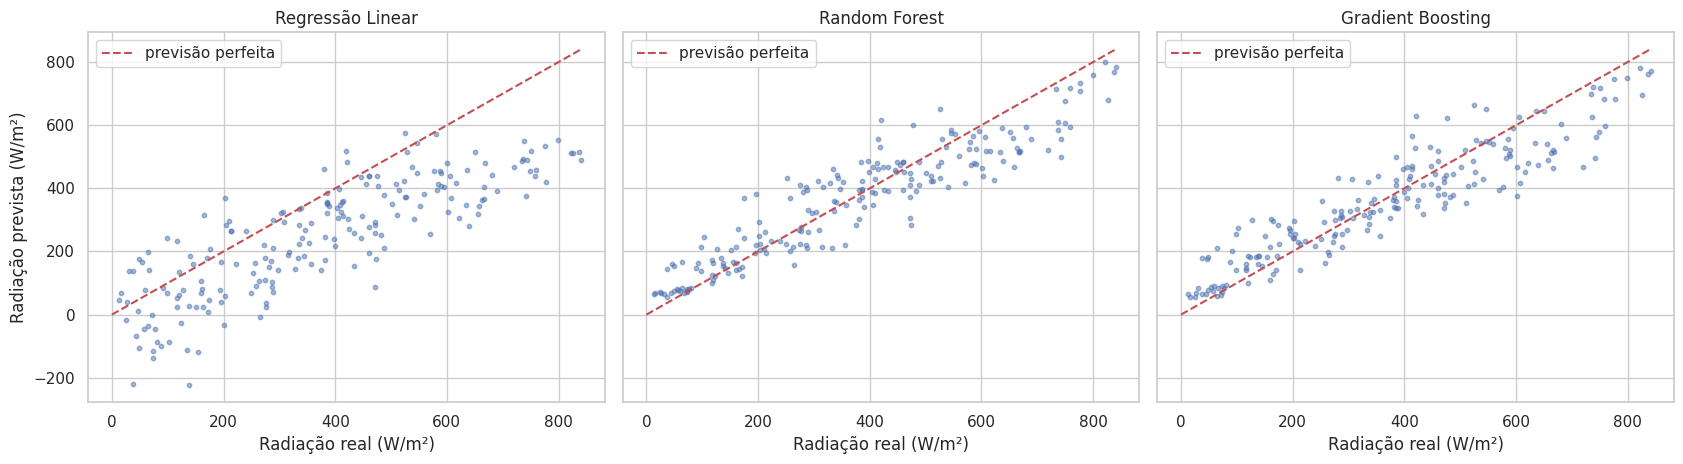

In [43]:
# Real x previsto para os três modelos
lim = [0, max(y_teste.max(), max(p.max() for p in previsoes.values()))]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True)
for ax, (nome, pred) in zip(axes, previsoes.items()):
    ax.scatter(y_teste, pred, s=10, alpha=0.5)
    ax.plot(lim, lim, "r--", label="previsão perfeita")
    ax.set_title(nome)
    ax.set_xlabel("Radiação real (W/m²)")
    ax.legend()
axes[0].set_ylabel("Radiação prevista (W/m²)")
plt.tight_layout(); plt.show()

### Erros e peso da hora

In [44]:
# Tamanho do erro em relação ao nível médio da radiação
media_teste = y_teste.mean()
print(f"Radiação média no teste: {media_teste:.1f} W/m²")
for nome, linha in tabela.iterrows():
    print(f"{nome:20s} MAE = {linha['MAE (W/m²)']:.1f} W/m²  ({100 * linha['MAE (W/m²)'] / media_teste:.1f}% da média)")

Radiação média no teste: 373.4 W/m²
Regressão Linear     MAE = 145.2 W/m²  (38.9% da média)
Random Forest        MAE = 66.1 W/m²  (17.7% da média)
Gradient Boosting    MAE = 68.2 W/m²  (18.3% da média)


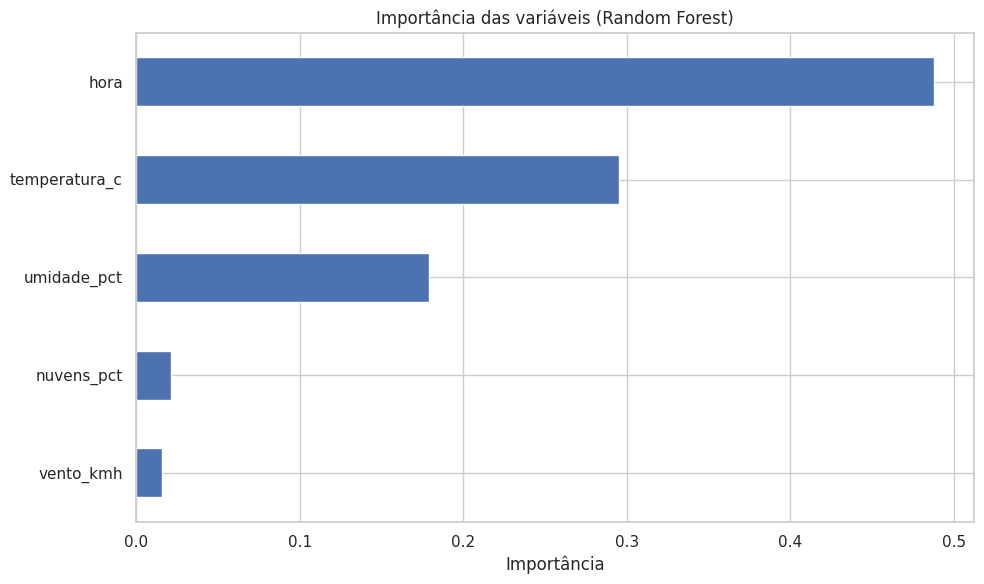

,0
hora,0.488
temperatura_c,0.295
umidade_pct,0.179
nuvens_pct,0.022
vento_kmh,0.016


In [45]:
# Peso de cada variável (Random Forest) — importante para discutir a hora
rf = modelos["Random Forest"][-1]
importancia = pd.Series(rf.feature_importances_, index=colunas_x).sort_values()
importancia.plot(kind="barh", title="Importância das variáveis (Random Forest)")
plt.xlabel("Importância"); plt.tight_layout(); plt.show()
importancia.sort_values(ascending=False).round(3)

### Interpretação dos erros, peso da hora e limites da estimativa

#### Interpretação dos erros:

- **Melhor modelo:** O **Random Forest** apresentou o melhor desempenho com um MAE de **66.1 W/m²**, o que representa cerca de **17.7%** da radiação média no período de teste (373.4 W/m²). O Gradient Boosting teve um desempenho muito próximo, com MAE de 68.2 W/m² (18.3% da média).
- **Regressão Linear:** Este modelo teve um desempenho significativamente inferior, com um MAE de 145.2 W/m² (38.9% da média) e um R² muito baixo (0.360). Isso reforça que a relação entre as variáveis de entrada e a radiação solar não é linear, e um modelo mais complexo é necessário para capturar os padrões observados.
- **Gráficos Real x Previsto:** Nos gráficos de dispersão, é visível que os modelos de Random Forest e Gradient Boosting (à direita) têm uma dispersão de pontos muito mais próxima da linha de previsão perfeita em comparação com a Regressão Linear. Isso indica que esses modelos conseguem prever a radiação com maior precisão na maioria dos casos. No entanto, ainda há pontos mais dispersos, especialmente para valores de radiação mais altos, o que pode indicar momentos de maior variabilidade ou eventos que as variáveis disponíveis não explicam totalmente (por exemplo, mudanças rápidas na cobertura de nuvens não capturadas em detalhes suficientes).

#### Peso da hora:

A análise de importância das variáveis do modelo Random Forest revela que a `hora` é, de longe, a variável mais influente na previsão da radiação solar, com uma importância de **0.488**. Isso faz todo o sentido, pois a radiação solar segue um ciclo diário bem definido, aumentando do amanhecer até o meio-dia e diminuindo até o pôr do sol. A `temperatura_c` também se mostrou bastante importante (0.295), seguida pela `umidade_pct` (0.179). A `nuvens_pct` e `vento_kmh`, embora relevantes fisicamente, tiveram um peso menor na previsão deste modelo.

#### Por que esta estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico:

É crucial entender que a estimativa da radiação solar em W/m² **não se traduz diretamente em energia gerada por um painel solar** devido a diversos fatores:

- **Radiação vs. Energia:** A radiação (W/m²) é uma medida de **potência** por unidade de área em um dado instante. A **energia** (kWh) é a potência integrada ao longo do tempo (kWh = kW * h). Para obter a energia, seria necessário integrar a potência horária e multiplicar pela área dos painéis.
- **Eficiência dos módulos:** Os painéis fotovoltaicos possuem uma eficiência específica (e.g., 15-22%) na conversão de luz solar em eletricidade. Essa eficiência varia entre diferentes tecnologias e fabricantes.
- **Inclinação e orientação:** A radiação medida aqui é **horizontal**. Painéis solares são instalados com uma **inclinação e orientação** específicas para maximizar a captação de radiação durante o dia e ao longo do ano. A radiação incidente no plano do painel é diferente da radiação horizontal.
- **Temperatura das células:** A eficiência dos painéis diminui com o aumento da temperatura das células, o que não é diretamente capturado pela radiação ou pela temperatura ambiente simples.
- **Perdas:** Existem perdas de energia devido a sujeira nos painéis (poeira, folhas, etc.), sombreamento (prédios, árvores, nuvens), perdas nos cabos (fiação) e na conversão da corrente contínua (CC) para corrente alternada (CA) pelo inversor.
- **Fonte dos dados:** Os dados do Open-Meteo são estimativas históricas baseadas em modelos/reanálise, não medições diretas de um sensor local. Embora úteis para análise climática, podem não ter a precisão necessária para uma predição exata de geração de energia fotovoltaica em um local específico.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)